# RetailPipe 5-Minute Event-Time Micro-Batch Pipeline Simulation

---

## Introduction

This notebook simulates a **Data Engineering incremental micro-batch pipeline** using the **Olist Brazilian E-Commerce dataset** from Kaggle.

### What is Olist?
Olist is a **static historical dataset** from Kaggle. It contains real Brazilian e-commerce orders from 2016 to 2018. It is **not a live stream** — it is a fixed CSV dataset.

### What are we simulating?
Instead of processing the full dataset as one block, we simulate **new orders arriving gradually** using 5-minute event-time micro-batches:

- The pipeline checks one **5-minute event-time window** at a time, using real `order_purchase_timestamp` values.
- If real Olist orders exist in that 5-minute window, the producer releases them into the landing zone.
- If no orders exist in that window, the producer skips it and moves to the next 5-minute window.
- We do **not generate fake orders** — only real Olist orders are used.



---

| Concept | Detail |
|---|---|
| Data Source | Olist Brazilian E-Commerce (Kaggle) |
| Batch Mode | 5-minute event-time micro-batch (not full dataset, not streaming) |
| Order Selection | Real orders that arrived in each 5-minute window (by `order_purchase_timestamp`) |
| Batch Size | Determined by real order density per 5-minute window |
| Airflow Readiness | Producer and consumer functions are Airflow-ready |


---
## 1. Imports


In [2]:
import os
import json
import shutil
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from IPython.display import display

print("All imports loaded successfully.")

All imports loaded successfully.


---
## 2. Folder Structure

We create four main folders to organise the pipeline:

| Folder | Purpose |
|---|---|
| `data/raw_source` | Stores the original Kaggle CSV files downloaded from KaggleHub |
| `data/landing` | Stores the newly arrived micro-batch waiting to be processed |
| `data/processed` | Stores batch files after they have been validated and processed |
| `data/batch_outputs` | Stores batch KPI results — `batch_summary.csv` and `daily_summary.csv` live here |


In [3]:
folders = [
    "data/raw_source",
    "data/landing",
    "data/processed",
    "data/batch_outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Folder ready: {folder}")

print("\nAll pipeline folders are ready.")

Folder ready: data/raw_source
Folder ready: data/landing
Folder ready: data/processed
Folder ready: data/batch_outputs

All pipeline folders are ready.


---
## 3. Raw Data Collection

We use **KaggleHub** to download the Olist Brazilian E-Commerce dataset automatically.

After downloading, all CSV files are copied into `data/raw_source` so the pipeline always reads from a local controlled folder.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\TEST\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [5]:
# Copy all CSV files from the downloaded path into data/raw_source
csv_files_found = [f for f in os.listdir(path) if f.endswith(".csv")]

for csv_file in csv_files_found:
    src = os.path.join(path, csv_file)
    dst = os.path.join("data/raw_source", csv_file)
    shutil.copy2(src, dst)

print(f"Copied {len(csv_files_found)} CSV files into data/raw_source.")
print("Files copied:", csv_files_found)

Copied 9 CSV files into data/raw_source.
Files copied: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [6]:
# Load all CSV files from data/raw_source into a dictionary called dataframes
dataframes = {}

for csv_file in os.listdir("data/raw_source"):
    if csv_file.endswith(".csv"):
        table_name = csv_file.replace(".csv", "")
        dataframes[table_name] = pd.read_csv(os.path.join("data/raw_source", csv_file))

print("Loaded tables:")
for name, df in dataframes.items():
    print(f"  {name}")

Loaded tables:
  olist_customers_dataset
  olist_geolocation_dataset
  olist_orders_dataset
  olist_order_items_dataset
  olist_order_payments_dataset
  olist_order_reviews_dataset
  olist_products_dataset
  olist_sellers_dataset
  product_category_name_translation


---
## 4. Extract Main DataFrames

We extract each table into its own named variable for clarity throughout the notebook.

`orders_df` is sorted by `order_purchase_timestamp` — this is the chronological order used by the 5-minute event-time micro-batch producer.


In [7]:
# Extract all main DataFrames from the loaded dictionary
customers_df             = dataframes.get("olist_customers_dataset", pd.DataFrame())
orders_df                = dataframes.get("olist_orders_dataset", pd.DataFrame())
order_items_df           = dataframes.get("olist_order_items_dataset", pd.DataFrame())
products_df              = dataframes.get("olist_products_dataset", pd.DataFrame())
sellers_df               = dataframes.get("olist_sellers_dataset", pd.DataFrame())
order_payments_df        = dataframes.get("olist_order_payments_dataset", pd.DataFrame())
order_reviews_df         = dataframes.get("olist_order_reviews_dataset", pd.DataFrame())
category_translation_df  = dataframes.get("product_category_name_translation", pd.DataFrame())
geolocation_df           = dataframes.get("olist_geolocation_dataset", pd.DataFrame())

# Convert order_purchase_timestamp to datetime and sort orders chronologically
orders_df["order_purchase_timestamp"] = pd.to_datetime(orders_df["order_purchase_timestamp"])
orders_df = orders_df.sort_values("order_purchase_timestamp").reset_index(drop=True)

print("Main DataFrames extracted and orders sorted successfully.")

Main DataFrames extracted and orders sorted successfully.


---
## 4a. Integrated Inventory Source Table

> **Inventory is created as an integrated simulated source table** because Olist does not include real stock data. During each batch, order_items are joined with `inventory_df`, so inventory KPIs are calculated inside the same pipeline with sales/order KPIs.

`inventory_df` is built from **all unique `product_id` + `seller_id` pairs** in `order_items_df`. Only `stock_qty` and `reorder_level` are simulated — all other fields come directly from the real Olist data.

| Column | Source |
|---|---|
| `inventory_id` | Auto-incremented key |
| `product_id` | From `order_items_df` |
| `seller_id` | From `order_items_df` |
| `inventory_date` | Simulated snapshot date |
| `stock_qty` | **Simulated** |
| `reorder_level` | **Simulated** |
| `stock_status` | Derived: `Out of Stock` / `Low Stock` / `In Stock` |

Saved to `data/raw_source/inventory.csv` and added to `dataframes["inventory"]`.


In [8]:
import random
random.seed(42)
np.random.seed(42)

# Build inventory_df from all unique product_id + seller_id pairs in order_items_df
inventory_pairs = (
    order_items_df[["product_id", "seller_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

n = len(inventory_pairs)

# Simulate stock_qty and reorder_level
stock_qty = np.random.choice(
    [0, 0, 0, 5, 10, 15, 20, 30, 50, 75, 100],
    size=n
)

reorder_level = np.random.choice(
    [5, 10, 15, 20, 25, 30],
    size=n
)

# stock_status logic
def get_stock_status(qty, reorder):
    if qty == 0:
        return "Out of Stock"
    elif qty < reorder:
        return "Low Stock"
    else:
        return "In Stock"

inventory_df = inventory_pairs.copy()
inventory_df.insert(0, "inventory_id", range(1, n + 1))
inventory_df["inventory_date"] = pd.Timestamp("2018-10-01")
inventory_df["stock_qty"] = stock_qty
inventory_df["reorder_level"] = reorder_level
inventory_df["stock_status"] = [
    get_stock_status(q, r) 
    for q, r in zip(stock_qty, reorder_level)
]

# Save to data/raw_source/inventory.csv
inventory_df.to_csv("data/raw_source/inventory.csv", index=False)

# Add to dataframes dictionary
dataframes["inventory"] = inventory_df

print("inventory_df created and saved as data/raw_source/inventory.csv")

inventory_df created and saved as data/raw_source/inventory.csv


---
## 5. Source Readiness Check

The project treats the data source as an operational source where orders arrive gradually every 5 minutes. Because future incoming data is not explored before it arrives, we do not perform full exploration on the complete source dataset at the beginning. At this stage, we only confirm that the required source tables are available. Each incoming batch is validated during processing, and the main exploration is performed later on processed outputs such as `batch_summary.csv` and `daily_summary.csv`.



In [9]:
# Confirm all required source tables are available
source_table_names = [
    "customers",
    "orders",
    "order_items",
    "products",
    "sellers",
    "order_payments",
    "order_reviews",
    "geolocation",
    "product_category_name_translation",
    "inventory",
]

source_tables_df = pd.DataFrame({"table_name": source_table_names})
print("Source tables available:")
display(source_tables_df)
print(f"\nAll {len(source_table_names)} source tables confirmed available.")


Source tables available:


,table_name
0,customers
1,orders
2,order_items
3,products
4,sellers
5,order_payments
6,order_reviews
7,geolocation
8,product_category_name_translation
9,inventory



All 10 source tables confirmed available.


---
## Pipeline State Management

The pipeline tracks its progress using a small JSON state file: `data/pipeline_state.json`.

| Field | Purpose |
|---|---|
| `current_window_start` | The start of the next 5-minute event-time window to check |
| `next_batch_id` | The ID of the next batch to be released — starts at 1 |

The `reset_pipeline_state()` function clears the landing, processed, and batch_outputs folders and resets the state file — **without deleting raw source data or loaded DataFrames**.


In [10]:
STATE_FILE = "data/pipeline_state.json"

def _get_initial_state():
    """Build the initial state using the minimum order_purchase_timestamp."""
    min_ts = orders_df["order_purchase_timestamp"].min()
    return {
        "current_window_start": str(min_ts),
        "next_batch_id": 1
    }

def _load_state():
    """Load the pipeline state from disk. Create it if it doesn't exist."""
    if not os.path.exists(STATE_FILE):
        initial = _get_initial_state()
        with open(STATE_FILE, "w") as f:
            json.dump(initial, f, indent=2)
    with open(STATE_FILE, "r") as f:
        return json.load(f)

def _save_state(state):
    """Save the pipeline state to disk."""
    with open(STATE_FILE, "w") as f:
        json.dump(state, f, indent=2)

def _clear_folder_contents(folder_path):
    """Remove all files inside a folder without deleting the folder itself."""
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)
        if os.path.isfile(item_path):
            os.remove(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)

def reset_pipeline_state():
    """
    Reset the pipeline to its initial state.
    - Clears data/landing, data/processed, and data/batch_outputs folders.
    - Sets current_window_start to the minimum order_purchase_timestamp.
    - Sets next_batch_id to 1.
    - Does NOT delete data/raw_source or loaded DataFrames.
    """
    _clear_folder_contents("data/landing")
    print("Landing folder cleared.")

    _clear_folder_contents("data/processed")
    print("Processed folder cleared.")

    _clear_folder_contents("data/batch_outputs")
    print("Batch outputs folder cleared.")

    initial = _get_initial_state()
    _save_state(initial)
    print("Pipeline state reset successfully.")
    print(f"  current_window_start set to: {initial['current_window_start']}")
    print(f"  next_batch_id set to: {initial['next_batch_id']}")
    print("The pipeline will start from the first real order timestamp.")

# Initialize state file if it doesn't exist yet
_load_state()
print("Pipeline state initialised.")
print("Current state:", json.dumps(_load_state(), indent=2))

Pipeline state initialised.
Current state: {
  "current_window_start": "2016-09-04 21:15:19",
  "next_batch_id": 1
}


---
## Minute Event-Time Order Producer

The **producer** checks one 5-minute event-time window at a time using real `order_purchase_timestamp` values.

**Key rules:**
- The window is defined by `current_window_start` and `current_window_end = current_window_start + 5 minutes`.
- Only real Olist orders whose `order_purchase_timestamp` falls in that window are released.
- If no orders exist in the window, the producer moves to the next window without creating any files.
- The landing folder must be **empty** before a new batch is released.
- Related `order_items`, `order_payments`, and `order_reviews` are filtered by the released `order_id` values.



In [11]:
def release_next_5min_order_batch():
    """
    Release the next 5-minute event-time window of real Olist orders into data/landing.

    - Uses current_window_start from the state file.
    - Checks orders where order_purchase_timestamp >= window_start and < window_end.
    - If orders exist, saves batch files and advances the window.
    - If no orders exist, advances the window without creating files.
    - The landing folder must be empty before a new batch is released.
    """

    # --- Guard: landing must be empty ---
    landing_files = os.listdir("data/landing")
    if len(landing_files) > 0:
        print("Landing folder is not empty. Process the current batch before releasing a new one.")
        return

    # --- Load pipeline state ---
    state = _load_state()
    current_window_start = pd.Timestamp(state["current_window_start"])
    next_batch_id        = state["next_batch_id"]

    max_order_purchase_timestamp = orders_df["order_purchase_timestamp"].max()
    if current_window_start >= max_order_purchase_timestamp:
        print("No more orders to release.")
        return

    # --- Define the 5-minute window ---
    current_window_end = current_window_start + pd.Timedelta(minutes=5)

    # --- Filter orders in this window ---
    mask = (
        (orders_df["order_purchase_timestamp"] >= current_window_start) &
        (orders_df["order_purchase_timestamp"] < current_window_end)
    )
    batch_orders = orders_df[mask].copy()

    # --- If no orders in this window, skip and advance ---
    if len(batch_orders) == 0:
        print(f"No new orders in this 5-minute window: {current_window_start} → {current_window_end}")
        state["current_window_start"] = str(current_window_end)
        _save_state(state)
        print("Window advanced. No batch files created. next_batch_id unchanged.")
        return

    # --- Get order IDs and filter related tables ---
    released_order_ids   = set(batch_orders["order_id"].tolist())
    batch_order_items    = order_items_df[order_items_df["order_id"].isin(released_order_ids)].copy()
    batch_order_payments = order_payments_df[order_payments_df["order_id"].isin(released_order_ids)].copy()
    batch_order_reviews  = order_reviews_df[order_reviews_df["order_id"].isin(released_order_ids)].copy()

    # --- Save batch files to data/landing ---
    batch_id_str = str(next_batch_id).zfill(4)

    batch_orders.to_csv(f"data/landing/orders_batch_{batch_id_str}.csv",         index=False)
    batch_order_items.to_csv(f"data/landing/order_items_batch_{batch_id_str}.csv",    index=False)
    batch_order_payments.to_csv(f"data/landing/order_payments_batch_{batch_id_str}.csv", index=False)
    batch_order_reviews.to_csv(f"data/landing/order_reviews_batch_{batch_id_str}.csv",  index=False)

    # --- Update pipeline state ---
    state["current_window_start"] = str(current_window_end)
    state["next_batch_id"]        = next_batch_id + 1
    _save_state(state)

    # --- Print release summary ---
    print(f"Batch Released: {batch_id_str}")
    print(f"  Window start:           {current_window_start}")
    print(f"  Window end:             {current_window_end}")
    print(f"  Orders released:        {len(batch_orders):,}")
    print(f"  Order items released:   {len(batch_order_items):,}")
    print(f"  Payments released:      {len(batch_order_payments):,}")
    print(f"  Reviews released:       {len(batch_order_reviews):,}")
    print(f"  Files saved to:         data/landing/")

print("Producer function release_next_5min_order_batch() is ready.")

Producer function release_next_5min_order_batch() is ready.


---
## 9. Batch Consumer Pipeline

The **consumer** picks up the micro-batch from the landing zone, validates it, calculates KPIs, saves the results to `batch_summary.csv`, and moves the processed files to `data/processed`.

**Validation checks performed:**
- Missing values in orders and order_items
- Duplicate orders and order_items
- Invalid prices (< 0) and invalid freight values (< 0)
- order_item `order_id` values exist in orders (referential integrity)
- order `customer_id` values exist in customers reference table
- order_item `product_id` values exist in products reference table
- order_item `seller_id` values exist in sellers reference table

**Batch quality status:**
- `"Passed"` — no validation issues found
- `"Needs Review"` — one or more validation checks failed

**Fields saved in batch_summary.csv:**
batch_id, window_start, window_end, total_orders, total_order_items, total_payments, total_reviews, unique_customers, unique_products, unique_sellers, sales_revenue, shipping_revenue, total_paid_amount, average_order_value, validation checks, batch_quality_status


In [12]:
def process_landing_batch():
    """
    Consume the current micro-batch from data/landing.

    Steps:
    1. Detect the batch_id from landing filenames.
    2. Check all four required files exist.
    3. Read the batch files.
    4. Validate the batch.
    5. Merge batch_items with inventory_df (product_id + seller_id, left join).
    6. Calculate batch KPIs including inventory KPIs.
    7. Append KPIs to data/batch_outputs/batch_summary.csv.
    8. Append inventory details to data/batch_outputs/batch_inventory_details.csv.
    9. Move processed files to data/processed.
    """

    BATCH_SUMMARY_PATH           = "data/batch_outputs/batch_summary.csv"
    BATCH_INVENTORY_DETAILS_PATH = "data/batch_outputs/batch_inventory_details.csv"

    # --- Check landing folder ---
    landing_files = os.listdir("data/landing")
    if not landing_files:
        print("No batch found in landing folder.")
        return

    # --- Detect batch_id from filenames ---
    batch_id_str = None
    for fname in landing_files:
        if fname.startswith("orders_batch_") and fname.endswith(".csv"):
            batch_id_str = fname.replace("orders_batch_", "").replace(".csv", "")
            break

    if batch_id_str is None:
        print("Could not detect batch_id from landing files. Expected 'orders_batch_XXXX.csv'.")
        return

    # --- Check all four required files exist ---
    required_files = [
        f"orders_batch_{batch_id_str}.csv",
        f"order_items_batch_{batch_id_str}.csv",
        f"order_payments_batch_{batch_id_str}.csv",
        f"order_reviews_batch_{batch_id_str}.csv",
    ]

    for req_file in required_files:
        if req_file not in landing_files:
            print(f"Missing required file: {req_file} — stopping without processing.")
            return

    # --- Check if this batch was already processed ---
    batch_id_int = int(batch_id_str)
    if os.path.exists(BATCH_SUMMARY_PATH):
        existing_summary = pd.read_csv(BATCH_SUMMARY_PATH)
        if batch_id_int in existing_summary["batch_id"].values:
            print(f"Batch {batch_id_str} already processed. Skipping.")
            return

    # --- Read batch files ---
    batch_orders   = pd.read_csv(f"data/landing/orders_batch_{batch_id_str}.csv")
    batch_items    = pd.read_csv(f"data/landing/order_items_batch_{batch_id_str}.csv")
    batch_payments = pd.read_csv(f"data/landing/order_payments_batch_{batch_id_str}.csv")
    batch_reviews  = pd.read_csv(f"data/landing/order_reviews_batch_{batch_id_str}.csv")

    batch_orders["order_purchase_timestamp"] = pd.to_datetime(
        batch_orders["order_purchase_timestamp"], errors="coerce"
    )

    # --- Merge batch_items with inventory_df (product_id + seller_id, left join) ---
    batch_items_inventory = batch_items.merge(
        inventory_df[["product_id", "seller_id", "stock_qty", "reorder_level", "stock_status"]],
        on=["product_id", "seller_id"],
        how="left"
    )

    # =====================================================
    # VALIDATION
    # =====================================================

    valid_customer_ids = set(customers_df["customer_id"].tolist())
    valid_product_ids  = set(products_df["product_id"].tolist())
    valid_seller_ids   = set(sellers_df["seller_id"].tolist())
    batch_order_ids    = set(batch_orders["order_id"].tolist())

    missing_values_orders      = int(batch_orders.isnull().sum().sum())
    missing_values_order_items = int(batch_items.isnull().sum().sum())
    duplicate_orders           = int(batch_orders.duplicated(subset="order_id").sum())
    duplicate_order_items      = int(batch_items.duplicated().sum())
    invalid_price_count        = int((batch_items["price"] < 0).sum())
    invalid_freight_count      = int((batch_items["freight_value"] < 0).sum())

    order_items_order_id_valid = int(
        (~batch_items["order_id"].isin(batch_order_ids)).sum()
    )
    orders_customer_id_valid = int(
        (~batch_orders["customer_id"].isin(valid_customer_ids)).sum()
    )
    order_items_product_id_valid = int(
        (~batch_items["product_id"].isin(valid_product_ids)).sum()
    )
    order_items_seller_id_valid = int(
        (~batch_items["seller_id"].isin(valid_seller_ids)).sum()
    )


    # =====================================================
    # KPI CALCULATION
    # =====================================================

    # Derive window_start and window_end from the state file for this batch
    state = _load_state()
    # window_end = current_window_start (already advanced), window_start = window_end - 5 min
    window_end_ts   = pd.Timestamp(state["current_window_start"])
    window_start_ts = window_end_ts - pd.Timedelta(minutes=5)

    total_orders        = len(batch_orders)
    total_order_items   = len(batch_items)
    total_payments      = len(batch_payments)
    total_reviews       = len(batch_reviews)
    unique_customers    = batch_orders["customer_id"].nunique()
    unique_products     = batch_items["product_id"].nunique() if "product_id" in batch_items.columns else 0
    unique_sellers      = batch_items["seller_id"].nunique() if "seller_id" in batch_items.columns else 0
    sales_revenue       = round(batch_items["price"].sum(), 2)
    shipping_revenue    = round(batch_items["freight_value"].sum(), 2)
    total_paid_amount   = round(sales_revenue + shipping_revenue, 2)

    # Average order value: group price by order_id, then take the mean
    if len(batch_items) > 0:
        avg_order_value = round(
            batch_items.groupby("order_id")["price"].sum().mean(), 2
        )
    else:
        avg_order_value = 0.0

    # =====================================================
    # INVENTORY KPIs (SIMPLIFIED)
    # =====================================================

    # Unique product-seller pairs by stock status (product-level view)
    dedup_inv         = batch_items_inventory.drop_duplicates(subset=["product_id", "seller_id"])
    inv_status_counts = dedup_inv["stock_status"].value_counts()
    low_stock_items     = int(inv_status_counts.get("Low Stock",    0))
    out_of_stock_items  = int(inv_status_counts.get("Out of Stock", 0))

    # Order item rows by stock status (order-item-level view)
    item_status_counts       = batch_items_inventory["stock_status"].value_counts()
    low_stock_order_items    = int(item_status_counts.get("Low Stock",    0))
    out_of_stock_order_items = int(item_status_counts.get("Out of Stock", 0))

    # True if ALL order items matched inventory (stock_status not NaN)
    inventory_match_valid = bool(batch_items_inventory["stock_status"].notna().all())
    # Quality status — recalculated here so inventory_match_valid is included
    batch_quality_status = (
        "Passed"
        if (
            duplicate_orders == 0
            and duplicate_order_items == 0
            and invalid_price_count == 0
            and invalid_freight_count == 0
            and order_items_order_id_valid == 0
            and orders_customer_id_valid == 0
            and order_items_product_id_valid == 0
            and order_items_seller_id_valid == 0
            and inventory_match_valid == True
        )
        else "Needs Review"
    )

    # =====================================================
    # BUILD KPI ROW
    # =====================================================

    kpi_row = {
        "batch_id":                      batch_id_int,
        "window_start":                  str(window_start_ts),
        "window_end":                    str(window_end_ts),
        "total_orders":                  total_orders,
        "total_order_items":             total_order_items,
        "total_payments":                total_payments,
        "total_reviews":                 total_reviews,
        "unique_customers":              unique_customers,
        "unique_products":               unique_products,
        "unique_sellers":                unique_sellers,
        "sales_revenue":                 sales_revenue,
        "shipping_revenue":              shipping_revenue,
        "total_paid_amount":             total_paid_amount,
        "average_order_value":           avg_order_value,
        "missing_values_orders":         missing_values_orders,
        "missing_values_order_items":    missing_values_order_items,
        "duplicate_orders":              duplicate_orders,
        "duplicate_order_items":         duplicate_order_items,
        "invalid_price_count":           invalid_price_count,
        "invalid_freight_count":         invalid_freight_count,
        "order_items_order_id_valid":    order_items_order_id_valid,
        "orders_customer_id_valid":      orders_customer_id_valid,
        "order_items_product_id_valid":  order_items_product_id_valid,
        "order_items_seller_id_valid":   order_items_seller_id_valid,
        "batch_quality_status":          batch_quality_status,
        "inventory_match_valid":         inventory_match_valid,
        "low_stock_items":               low_stock_items,
        "out_of_stock_items":            out_of_stock_items,
        "low_stock_order_items":         low_stock_order_items,
        "out_of_stock_order_items":      out_of_stock_order_items,
    }

    kpi_df = pd.DataFrame([kpi_row])

    # --- Append to batch_summary.csv ---
    if os.path.exists(BATCH_SUMMARY_PATH):
        kpi_df.to_csv(BATCH_SUMMARY_PATH, mode="a", header=False, index=False)
    else:
        kpi_df.to_csv(BATCH_SUMMARY_PATH, index=False)

    # --- Create batch_inventory_details and append ---
    batch_inventory_details = batch_items_inventory[[
        "order_id", "product_id", "seller_id",
        "stock_qty", "reorder_level", "stock_status"
    ]].copy()
    batch_inventory_details.insert(0, "batch_id",     batch_id_int)
    batch_inventory_details.insert(1, "window_start", str(window_start_ts))
    batch_inventory_details.insert(2, "window_end",   str(window_end_ts))

    if os.path.exists(BATCH_INVENTORY_DETAILS_PATH):
        batch_inventory_details.to_csv(BATCH_INVENTORY_DETAILS_PATH, mode="a", header=False, index=False)
    else:
        batch_inventory_details.to_csv(BATCH_INVENTORY_DETAILS_PATH, index=False)

    # --- Move processed files from landing to processed ---
    for req_file in required_files:
        src = os.path.join("data/landing", req_file)
        dst = os.path.join("data/processed", req_file)
        shutil.move(src, dst)

    # --- Print processing summary ---
    print(f"Batch {batch_id_str} processed successfully.")
    print(f"  Window start:              {window_start_ts}")
    print(f"  Window end:                {window_end_ts}")
    print(f"  Total orders:              {total_orders:,}")
    print(f"  Total order items:         {total_order_items:,}")
    print(f"  Total payments:            {total_payments:,}")
    print(f"  Total reviews:             {total_reviews:,}")
    print(f"  Sales revenue:             R$ {sales_revenue:,.2f}")
    print(f"  Total paid amount:         R$ {total_paid_amount:,.2f}")
    print(f"  Average order value:       R$ {avg_order_value:,.2f}")
    print(f"  Quality status:            {batch_quality_status}")
    print(f"  Inventory match valid:     {inventory_match_valid}")
    print(f"  Low stock items:           {low_stock_items:,}")
    print(f"  Out of stock items:        {out_of_stock_items:,}")
    print(f"  Low stock order items:     {low_stock_order_items:,}")
    print(f"  Out of stock order items:  {out_of_stock_order_items:,}")
    print(f"  Files moved to:            data/processed/")
    print(f"  KPIs saved to:             {BATCH_SUMMARY_PATH}")
    print(f"  Inv. details saved to:     {BATCH_INVENTORY_DETAILS_PATH}")

print("Consumer function process_landing_batch() is ready.")


Consumer function process_landing_batch() is ready.


---
## 10. Demo: Release and Process One 5-Minute Order Batch

**Run this demo cell manually.** Each run simulates one 5-minute check. If real orders exist in that 5-minute event-time window, the producer releases them into the landing folder and the consumer processes them. If no orders exist, the producer moves to the next 5-minute window without creating batch files.

> **Note:** Call `reset_pipeline_state()` only if you want to restart from the very first order timestamp.


Run these lines manually only when testing the simulation. They are commented out so Run All does not accidentally process new batches.

In [13]:
release_next_5min_order_batch()
process_landing_batch()


Batch Released: 0001
  Window start:           2016-09-04 21:15:19
  Window end:             2016-09-04 21:20:19
  Orders released:        1
  Order items released:   2
  Payments released:      1
  Reviews released:       1
  Files saved to:         data/landing/
Batch 0001 processed successfully.
  Window start:              2016-09-04 21:15:19
  Window end:                2016-09-04 21:20:19
  Total orders:              1
  Total order items:         2
  Total payments:            1
  Total reviews:             1
  Sales revenue:             R$ 72.89
  Total paid amount:         R$ 136.23
  Average order value:       R$ 72.89
  Quality status:            Passed
  Inventory match valid:     True
  Low stock items:           1
  Out of stock items:        0
  Low stock order items:     1
  Out of stock order items:  0
  Files moved to:            data/processed/
  KPIs saved to:             data/batch_outputs/batch_summary.csv
  Inv. details saved to:     data/batch_outputs/batch_inve

---
## 11. Post-Pipeline Data Exploration

This is the main exploration section. It reads from processed pipeline outputs only —  Business exploration is performed here after the pipeline has processed incoming 5-minute batches.

**Sources used:**
- `data/batch_outputs/batch_summary.csv` — one row per processed batch
- `data/batch_outputs/daily_summary.csv` — daily aggregated KPIs

If no processed output is found, a friendly message is shown.


In [14]:
BATCH_SUMMARY_PATH           = "data/batch_outputs/batch_summary.csv"
DAILY_SUMMARY_PATH           = "data/batch_outputs/daily_summary.csv"
BATCH_INVENTORY_DETAILS_PATH = "data/batch_outputs/batch_inventory_details.csv"

if not os.path.exists(BATCH_SUMMARY_PATH):
    print("No processed output found yet. Run the producer and consumer manually to generate batch_summary.csv and daily_summary.csv.")
else:
    batch_summary_df = pd.read_csv(BATCH_SUMMARY_PATH)

    # Create a date column from window_start
    batch_summary_df["window_start"] = pd.to_datetime(batch_summary_df["window_start"])
    batch_summary_df["date"] = batch_summary_df["window_start"].dt.date

    # Aggregate by date
    daily_agg = batch_summary_df.groupby("date").agg(
        daily_orders           = ("total_orders",       "sum"),
        daily_sales_revenue    = ("sales_revenue",      "sum"),
        daily_shipping_revenue = ("shipping_revenue",   "sum"),
        daily_total_paid       = ("total_paid_amount",  "sum"),
        processed_batches      = ("batch_id",           "count")
    ).reset_index()

    # Daily average order value
    daily_agg["daily_average_order_value"] = (
        daily_agg["daily_sales_revenue"] / daily_agg["daily_orders"]
    ).round(2)

    daily_summary_df = daily_agg.copy()

    # =====================================================
    # DAILY INVENTORY KPIs (from batch_inventory_details)
    # We track Low Stock and Out of Stock only.
    # =====================================================
    if os.path.exists(BATCH_INVENTORY_DETAILS_PATH):
        batch_inv_df = pd.read_csv(BATCH_INVENTORY_DETAILS_PATH)
        batch_inv_df["window_start"] = pd.to_datetime(batch_inv_df["window_start"])
        batch_inv_df["date"] = batch_inv_df["window_start"].dt.date

        # Order-item-level inventory KPIs per day
        daily_inv_oi = batch_inv_df.groupby("date").agg(
            daily_low_stock_order_items    = ("stock_status", lambda x: int((x == "Low Stock").sum())),
            daily_out_of_stock_order_items = ("stock_status", lambda x: int((x == "Out of Stock").sum())),
        ).reset_index()

        # Unique product-seller pair inventory KPIs per day
        dedup_pairs = batch_inv_df.drop_duplicates(subset=["date", "product_id", "seller_id"])
        daily_inv_unique = dedup_pairs.groupby("date").agg(
            daily_low_stock_items    = ("stock_status", lambda x: int((x == "Low Stock").sum())),
            daily_out_of_stock_items = ("stock_status", lambda x: int((x == "Out of Stock").sum())),
        ).reset_index()

        # Merge inventory KPIs into daily_summary_df
        daily_summary_df = daily_summary_df.merge(daily_inv_oi,    on="date", how="left")
        daily_summary_df = daily_summary_df.merge(daily_inv_unique, on="date", how="left")

        inv_kpi_cols = [
            "daily_low_stock_order_items", "daily_out_of_stock_order_items",
            "daily_low_stock_items",       "daily_out_of_stock_items",
        ]
        daily_summary_df[inv_kpi_cols] = daily_summary_df[inv_kpi_cols].fillna(0).astype(int)

    else:
        # Add zero-filled columns so the CSV schema is always consistent
        for col in ["daily_low_stock_order_items", "daily_out_of_stock_order_items",
                    "daily_low_stock_items",       "daily_out_of_stock_items"]:
            daily_summary_df[col] = 0

    # Save daily_summary.csv (with inventory KPIs)
    daily_summary_df.to_csv(DAILY_SUMMARY_PATH, index=False)
    print(f"daily_summary.csv saved to {DAILY_SUMMARY_PATH}")

    # =====================================================
    # POST-PIPELINE EXPLORATION
    # =====================================================

    total_batches  = len(batch_summary_df)
    total_orders   = int(batch_summary_df["total_orders"].sum())
    total_revenue  = round(float(batch_summary_df["sales_revenue"].sum()), 2)
    total_paid     = round(float(batch_summary_df["total_paid_amount"].sum()), 2)
    passed_batches = int((batch_summary_df["batch_quality_status"] == "Passed").sum())
    needs_review   = int((batch_summary_df["batch_quality_status"] == "Needs Review").sum())

    # Average order value from daily summary
    if len(daily_summary_df) > 0 and daily_summary_df["daily_orders"].sum() > 0:
        avg_order_value = round(
            float(daily_summary_df["daily_sales_revenue"].sum()) /
            float(daily_summary_df["daily_orders"].sum()), 2
        )
    else:
        avg_order_value = 0.0

    print(f"\n=== Post-Pipeline Exploration ===")
    print(f"  Total processed batches:   {total_batches:,}")
    print(f"  Total processed orders:    {total_orders:,}")
    print(f"  Total sales revenue:       R$ {total_revenue:,.2f}")
    print(f"  Total paid amount:         R$ {total_paid:,.2f}")
    print(f"  Average order value:       R$ {avg_order_value:,.2f}")
    print(f"  Passed batches:            {passed_batches:,}")
    print(f"  Needs Review batches:      {needs_review:,}")

    print(f"\n=== Daily Summary (head) ===")
    display(daily_summary_df.head())

    print(f"\n=== Batch Monitoring ===")
    monitoring_cols = ["batch_id", "window_start", "window_end", "total_orders", "batch_quality_status"]
    display(batch_summary_df[monitoring_cols].tail(10))


daily_summary.csv saved to data/batch_outputs/daily_summary.csv

=== Post-Pipeline Exploration ===
  Total processed batches:   1
  Total processed orders:    1
  Total sales revenue:       R$ 72.89
  Total paid amount:         R$ 136.23
  Average order value:       R$ 72.89
  Passed batches:            1
  Needs Review batches:      0

=== Daily Summary (head) ===


,date,daily_orders,daily_sales_revenue,daily_shipping_revenue,daily_total_paid,processed_batches,daily_average_order_value,daily_low_stock_order_items,daily_out_of_stock_order_items,daily_low_stock_items,daily_out_of_stock_items
0,2016-09-04,1,72.89,63.34,136.23,1,72.89,1,0,1,0



=== Batch Monitoring ===


,batch_id,window_start,window_end,total_orders,batch_quality_status
0,1,2016-09-04 21:15:19,2016-09-04 21:20:19,1,Passed


---
## 12. Monthly Business Charts

The pipeline processes orders every 5 minutes, but the final business charts are shown monthly. Daily summaries are still created first, then grouped into `monthly_summary.csv` to make the dashboard clearer and easier to read over longer periods.


These charts are created after the pipeline processes incoming 5-minute batches. They are based on `daily_summary.csv`, not directly on the complete raw source dataset. Inventory KPIs are calculated and saved in the output files, but the displayed charts focus on the main business sales/order KPIs.


,month_date,month,monthly_orders,monthly_sales_revenue,monthly_shipping_revenue,monthly_total_paid,processed_days,monthly_average_order_value
0,2016-09-01,2016-09,1,72.89,63.34,136.23,1,72.89


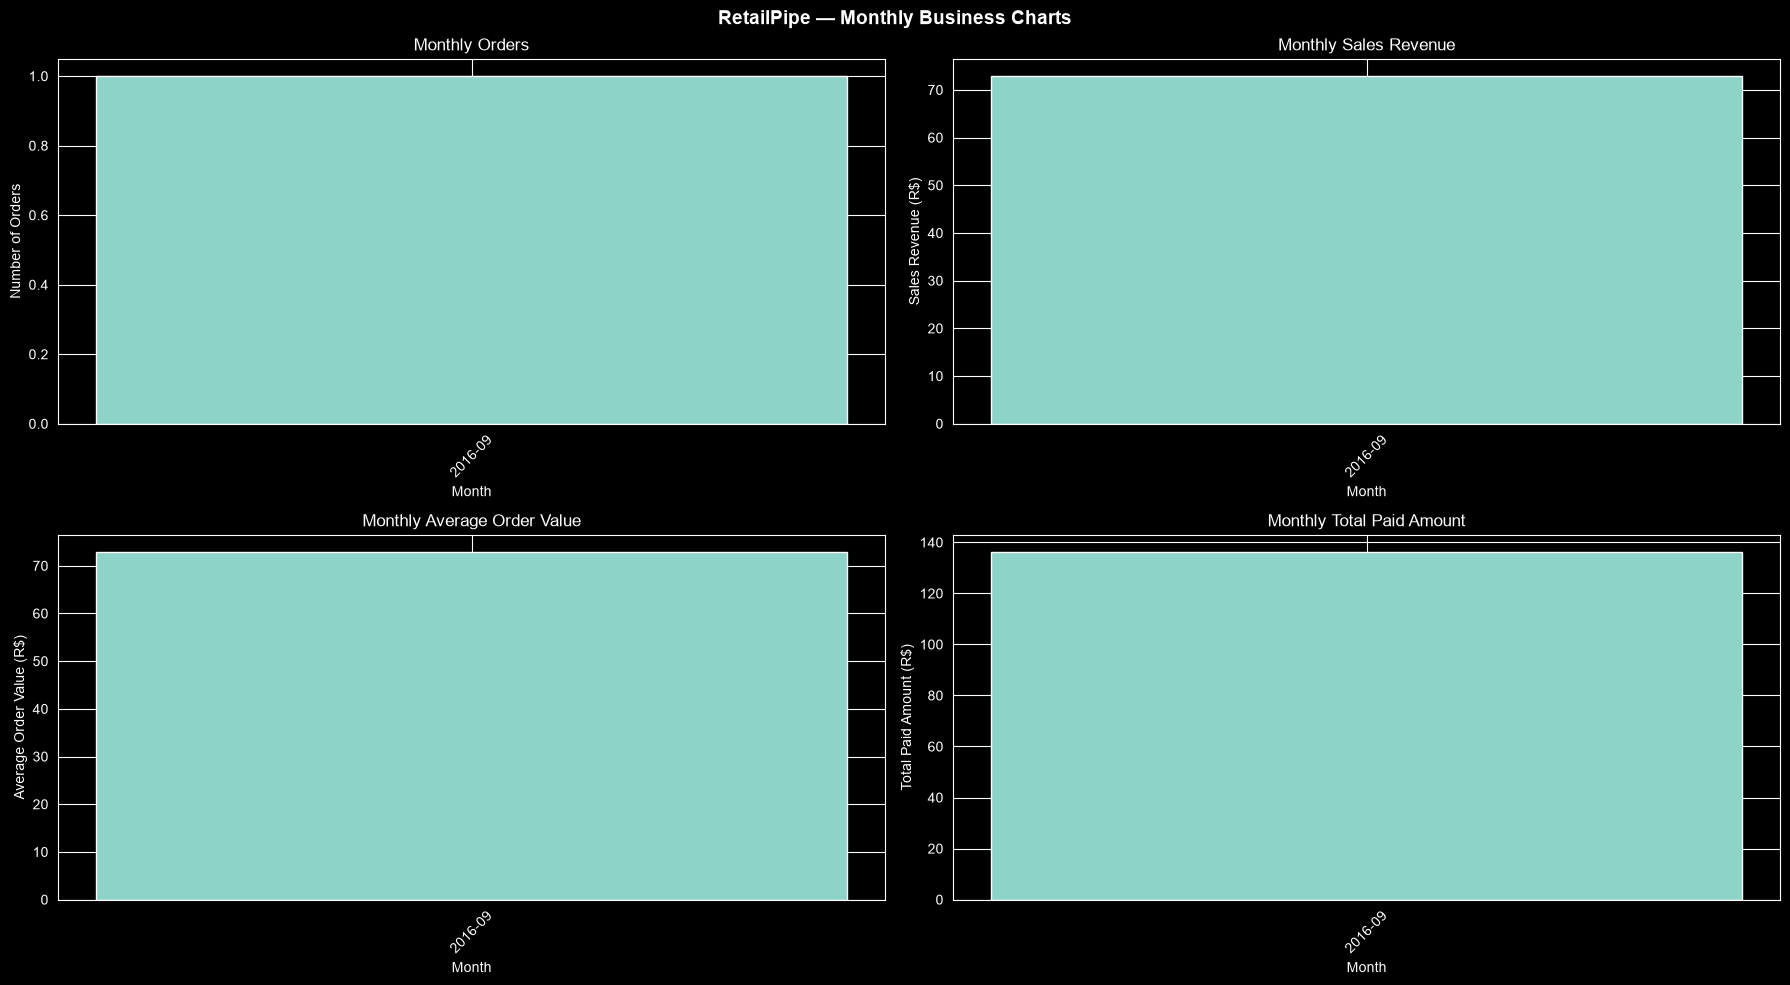

In [15]:
DAILY_SUMMARY_PATH = "data/batch_outputs/daily_summary.csv"
MONTHLY_SUMMARY_PATH = "data/batch_outputs/monthly_summary.csv"

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

if os.path.exists(DAILY_SUMMARY_PATH):
    daily_summary_df = pd.read_csv(DAILY_SUMMARY_PATH)

    if len(daily_summary_df) > 0:
        # Convert date column to datetime
        daily_summary_df["date"] = pd.to_datetime(daily_summary_df["date"])
        daily_summary_df = daily_summary_df.sort_values("date")

        # Create month column
        daily_summary_df["month"] = daily_summary_df["date"].dt.to_period("M").astype(str)

        # Aggregate daily processed outputs into monthly results
        monthly_summary_df = (
            daily_summary_df
            .groupby("month", as_index=False)
            .agg(
                monthly_orders=("daily_orders", "sum"),
                monthly_sales_revenue=("daily_sales_revenue", "sum"),
                monthly_shipping_revenue=("daily_shipping_revenue", "sum"),
                monthly_total_paid=("daily_total_paid", "sum"),
                processed_days=("date", "nunique")
            )
        )

        # Convert month to datetime
        monthly_summary_df["month_date"] = pd.to_datetime(monthly_summary_df["month"] + "-01")

        # Add all missing months between first and last month
        all_months = pd.date_range(
            start=monthly_summary_df["month_date"].min(),
            end=monthly_summary_df["month_date"].max(),
            freq="MS"
        )

        monthly_summary_df = (
            monthly_summary_df
            .set_index("month_date")
            .reindex(all_months)
            .rename_axis("month_date")
            .reset_index()
        )

        monthly_summary_df["month"] = monthly_summary_df["month_date"].dt.to_period("M").astype(str)

        # Fill missing month totals with zero
        fill_zero_columns = [
            "monthly_orders",
            "monthly_sales_revenue",
            "monthly_shipping_revenue",
            "monthly_total_paid",
            "processed_days"
        ]

        monthly_summary_df[fill_zero_columns] = monthly_summary_df[fill_zero_columns].fillna(0)

        # AOV should be NaN when there are no orders, not zero
        monthly_summary_df["monthly_average_order_value"] = np.where(
            monthly_summary_df["monthly_orders"] > 0,
            monthly_summary_df["monthly_sales_revenue"] / monthly_summary_df["monthly_orders"],
            np.nan
        )

        # Save monthly summary
        monthly_summary_df.to_csv(MONTHLY_SUMMARY_PATH, index=False)

        display(monthly_summary_df.head())

        x_labels = monthly_summary_df["month"]

        fig, axes = plt.subplots(2, 2, figsize=(18, 10))
        fig.suptitle(
            "RetailPipe — Monthly Business Charts",
            fontsize=14,
            fontweight="bold"
        )

        # Chart 1: Monthly Orders
        axes[0, 0].bar(
            x_labels,
            monthly_summary_df["monthly_orders"]
        )
        axes[0, 0].set_title("Monthly Orders")
        axes[0, 0].set_xlabel("Month")
        axes[0, 0].set_ylabel("Number of Orders")
        axes[0, 0].tick_params(axis="x", rotation=45)

        # Chart 2: Monthly Sales Revenue
        axes[0, 1].bar(
            x_labels,
            monthly_summary_df["monthly_sales_revenue"]
        )
        axes[0, 1].set_title("Monthly Sales Revenue")
        axes[0, 1].set_xlabel("Month")
        axes[0, 1].set_ylabel("Sales Revenue (R$)")
        axes[0, 1].tick_params(axis="x", rotation=45)

        # Chart 3: Monthly Average Order Value
        axes[1, 0].bar(
            x_labels,
            monthly_summary_df["monthly_average_order_value"]
        )
        axes[1, 0].set_title("Monthly Average Order Value")
        axes[1, 0].set_xlabel("Month")
        axes[1, 0].set_ylabel("Average Order Value (R$)")
        axes[1, 0].tick_params(axis="x", rotation=45)

        # Chart 4: Monthly Total Paid Amount
        axes[1, 1].bar(
            x_labels,
            monthly_summary_df["monthly_total_paid"]
        )
        axes[1, 1].set_title("Monthly Total Paid Amount")
        axes[1, 1].set_xlabel("Month")
        axes[1, 1].set_ylabel("Total Paid Amount (R$)")
        axes[1, 1].tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()

    else:
        print("Not enough daily data to create monthly charts yet.")

else:
    print("No daily_summary.csv found yet. Run the Post-Pipeline Data Exploration section first.")



### Airflow Integration Note

Airflow is **not implemented** in this notebook. However, the notebook is **Airflow-ready** because it has clear, decoupled producer and consumer functions.

In the next project step, Airflow can run every 5 minutes and call:
- `release_next_5min_order_batch()` — the producer DAG task
- `process_landing_batch()` — the consumer DAG task

Each Airflow run represents one 5-minute check for newly arrived orders:
1. The producer checks the next 5-minute event-time window.
2. If real orders exist, it releases them into `data/landing`.
3. The consumer validates the batch, calculates KPIs, and saves results.
4. Files are moved from landing to processed.

> **Important:** This is **scheduled event-time micro-batch processing** — not true real-time streaming.


---
## 13. Final Summary

| Item | Detail |
|---|---|
| **Data source** | Olist Brazilian E-Commerce — static Kaggle dataset |
| **Pipeline approach** | The source is treated as an operational data source where orders arrive gradually every 5 minutes |
| **Source exploration** | We do not explore all source data at the beginning — we only confirm that source tables are loaded (`source_tables_df`) |
| **Batch mode** | 5-minute event-time micro-batch using real `order_purchase_timestamp` values |
| **Batch validation** | Each 5-minute batch is validated during processing — missing values, duplicates, invalid prices, referential integrity, inventory match |
| **Producer** | `release_next_5min_order_batch()` — checks one 5-minute window per call |
| **Consumer** | `process_landing_batch()` — validates, calculates KPIs, moves files |
| **KPI calculation** | Sales/order KPIs and inventory KPIs are calculated during batch processing |
| **Batch output** | `data/batch_outputs/batch_summary.csv` — one row per processed batch |
| **Daily output** | `data/batch_outputs/daily_summary.csv` — daily aggregated KPIs |
| **Business exploration** | Performed after processing in the Post-Pipeline Data Exploration section using `batch_summary.csv` and `daily_summary.csv` |
| **Charts** | Monthly business charts (orders, revenue, AOV, total paid) — created from monthly_summary.csv, which is aggregated from daily_summary.csv|
| **Inventory KPIs** | Calculated during batch processing and saved in output files — not displayed as charts |
| **Airflow** | Not implemented here, but the notebook is Airflow-ready — producer and consumer are decoupled DAG-ready functions |

---
